## Projekt 2 - Analiza dynamiki czoła lodowca Kronebreen (Svalbard) za pomocą wskaźnika NDSI

### Wymagania projektowe i punktacja (20 pkt)
  
Celem projektu jest przygotowanie interaktywnego "podręcznika" („How-To”) w formie Jupyter Notebooka, w którym krok po kroku przeprowadzicie użytkownika przez pełen proces pobierania, przetwarzania i wizualizacji wybranej analizy na danych satelitarnych dostarczanych przez Microsoft Planetary Computer.
  
1. **Parametryzacja notebooka** (2 pkt)  
   - Sekcja na początku z definiowanymi zmiennymi:
     - `bbox = [xmin, ymin, xmax, ymax]`  
     - `date_range = "YYYY-MM-DD/YYYY-MM-DD"`  
     - opcjonalne filtry (jeśli potrzebne w analizie)  
   - Kod automatycznie odwołuje się do tych zmiennych, bez ręcznej edycji w dalszej części.

2. **Opis wybranej kolekcji** (2 pkt)  
   - Nazwa i charakterystyka kolekcji (sensor, rozdzielczość, typ produktu).  
   - Link do katalogu Planetary Computer.  
   - Uzasadnienie wyboru tej kolekcji dla wybranego scenariusza.

3. **Scenariusz analizy** (2 pkt)  
   - Jasne sformułowanie celu / pytania badawczego.  
   - Krótki opis metody np.:  
     - wzór na wskaźnik (np. NDVI, mNDWI, NBR)  
     - opis progowania / maskowania.  

4. **Implementacja krok po kroku** (6 pkt)  
   - Każdy fragment kodu poprzedzony komórką Markdown z wyjaśnieniem (po polsku lub angielsku, można utrzymać dowolny język dla całego notebooka).  
   - Przykładowe kolejne etapy:  
        - Importy i autoryzacja (AIO, licencje).
        - Tworzenie obiektu RasterCollection z STACAPI.
        - Eksploracja metadanych i atrybutów.
        - Filtrowanie scen 
        - Definicja funkcji obliczeniowej 
        - Zastosowanie funkcji na całej kolekcji (map).
        - Dalsze obliczenia (np. różnica między scenami, analizowanie trendów itp.)
     
5. **Wizualizacja wyników** (3 pkt)  
   - Wyświetlenie wynikowych rastrów (należy zadbać w miarę możliwości o symbolizację).  
   - Dodatkowe wykresy (np. histogram, wykres czasowy wartości wskaźnika dla wybranego piksela/obszaru)  
        
6. **Podsumowanie i uwagi** (2 pkt)  
   - Krótka interpretacja uzyskanych wyników.  
   - Ograniczenia wybranej metody i propozycje poprawek.  
   - Inne końcowe uwagi dla potencjalnego użytkownika.

7. **Kompleksowość i samodzielność** (1 pkt)  
   - Notebook musi być kompletny, czytelny i w pełni samodzielny.  
   - Jeśli wymagane pliki zewnętrzne (np. `.acs`), należy opisać, skąd je pobrać i jak ustawić ścieżki.  
   - Wszystkie ścieżki do zapisu wyników umieść w osobnej, wyróżnionej sekcji.

8.  **Prezentacja** (2 pkt)
    - na zajęciach należy przedstawić Notebook reszcie grupy i wyjaśnić co się w nim znajduje, jakie były trudności i jaki jest efekt pracy.  

### 1. Parametryzacja

In [ ]:
# Bounding box dla lodowca Kronebreen (Svalbard) TODO pokesperymentować z różnymi obszarami, zobaczyć co ten konkeretny pokazuje
bbox = [12.30, 78.80, 13.00, 78.95] 

# zakres dat TODO to chyba przestało byc używane
date_range = "2015-08-01/2023-08-31"

# maksymalne pokrycie chmur
max_cloud_cover = 20

### 2. Opis wybranej kolekcji
TODO

### 3. Scenariusz analizy
**Cel:** Identyfikacja cofania się czoła lodowca Kronebreen na przestrzeni kilku lat.  
**Metoda:** Wykorzystamy znormalizowany wskaźnik różnicowy śniegu (NDSI). Śnieg i lód silnie odbijają światło widzialne (szczególnie pasmo zielone), ale absorbują promieniowanie w średniej podczerwieni (SWIR). 

Wzór na wskaźnik NDSI:
$$\text{NDSI} = \frac{\text{Green} - \text{SWIR}}{\text{Green} + \text{SWIR}}$$

Piksele o wartości NDSI > 0.4 zazwyczaj klasyfikuje się jako pokrywę śnieżną/lodową.

### 4. Konfiguracja środowiska
W python command prompt (ważne!) należy sklonować bazowe środowisko zainstalowanego ArcGISa: `conda create --clone arcgispro-py3 --name sg_arcpy_37 --pinned` (to działa w moim przypadku, nie ręczę u was).

### 5. Implementacja

#### 5.1. Importy

In [6]:
import matplotlib.pyplot as plt
import arcpy
from arcpy.ia import *
from arcpy import AIO

#### 5.2. Autoryzacja i ładowanie pliku ACS
Plik `esrims_pc_landsat-c2-l2.acs` należy pobrać stad: https://github.com/Esri/arcgis-for-mpc/tree/874a88e21663709df3bb3e24f0b328381a485031/AMPC_Resources/ACS_Files i przenieść do podanej ścieżki

In [3]:
a = AIO(r"C:\Temp\ACS\esrims_pc_landsat-c2-l2.acs")

#### 5.3. Definiowanie zapytania STAC z użyciem wcześniej zdefiniowanych zmiennych

In [ ]:
# starsza scena (np. lato 2015)
query_old = {
    "collections": ["landsat-c2-l2"],
    "bbox": bbox,
    "query": {"eo:cloud_cover": {"lt": max_cloud_cover}},
    "datetime": "2015-06-01/2015-08-31",
    "limit": 1  # 1 najlepsze zdjęcie
}

# nowa scena (np. lato 2023)
query_new = {
    "collections": ["landsat-c2-l2"],
    "bbox": bbox,
    "query": {"eo:cloud_cover": {"lt": max_cloud_cover}},
    "datetime": "2023-06-01/2023-08-31",
    "limit": 1  # 1 najlepsze zdjęcie
}

# pobieranie kolekcji
rc_old = arcpy.ia.RasterCollection.fromSTACAPI("https://planetarycomputer.microsoft.com/api/stac/v1", query=query_old, attribute_dict={"Name":"id", "StdTime":"datetime"}).selectBands(["SR_B3", "SR_B6"])
rc_new = arcpy.ia.RasterCollection.fromSTACAPI("https://planetarycomputer.microsoft.com/api/stac/v1", query=query_new, attribute_dict={"Name":"id", "StdTime":"datetime"}).selectBands(["SR_B3", "SR_B6"])

#### 5.4. Definiowanie i mapowanie funkcji

In [ ]:
# funkcja do obliczania NDSI
def calc_ndsi(item):
    ras = item["Raster"]
    # pasmo 1 to SR_B3 (Zielone), a pasmo 2 to SR_B6 (SWIR), bo wcześniej wybraliśmy tylko te dwa pasma
    green, swir = ras.getRasterBands([1, 2])
    
    # Teraz możemy bezpiecznie wykonać algebrę rastrów
    ndsi_raster = (green - swir) / (green + swir)
    
    return {
        "raster": ndsi_raster,
        "Name": item["Name"],
        "StdTime": item["StdTime"]
    }

# mapowanie funkcji obliczającej NDSI na obu pojedynczych kolekcjach
ndsi_old_coll = rc_old.map(calc_ndsi)
ndsi_new_coll = rc_new.map(calc_ndsi)

# wyciąganie obiektów
raster_old = ndsi_old_coll[0]["Raster"]
raster_new = ndsi_new_coll[0]["Raster"]

### 6. Wizualizacja

Porównanie sceny z 2015-08-01 ze sceną z 2023-08-09.


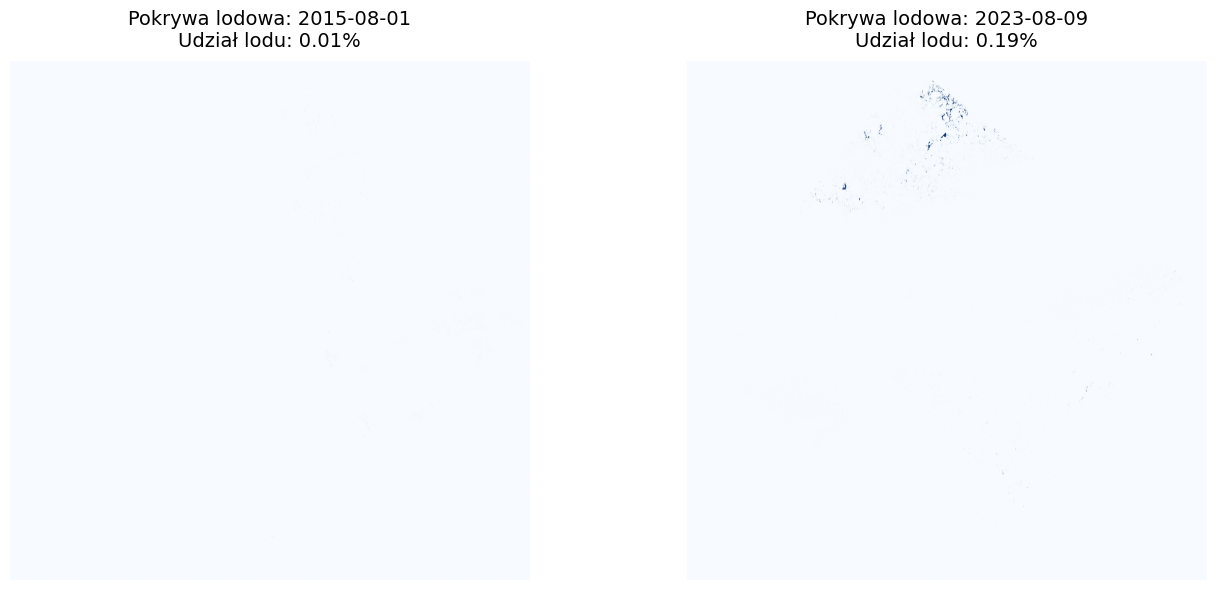

In [ ]:
# pobranie najstarszej i najnowszej sceny do porównania
date_old = str(ndsi_old_coll[0]["StdTime"])[:10]
date_new = str(ndsi_new_coll[0]["StdTime"])[:10]

print(f"Porównanie sceny z {date_old} ze sceną z {date_new}.")

# maska dla lodu (NDSI > 0.4)
ice_mask_old = Con(raster_old > 0.4, 1, 0)
ice_mask_new = Con(raster_new > 0.4, 1, 0)

# konwersja do NumPy z JAWNYM określeniem wartości dla NoData jako -1, dzięki temu puste obszary w rogach dostaną wartość -1
arr_old = arcpy.RasterToNumPyArray(ice_mask_old, nodata_to_value=-1)
arr_new = arcpy.RasterToNumPyArray(ice_mask_new, nodata_to_value=-1)

# procentowy udział lodu w bbox
# liczymy tylko piksele, które mają wartość 1 (lód)
ice_pixels_old = (arr_old == 1).sum()
# liczymy tylko piksele, które należą do zdjęcia (0 lub 1, czyli >= 0), ignorując NoData (-1)
valid_pixels_old = (arr_old >= 0).sum()
pct_old = (ice_pixels_old / valid_pixels_old) * 100

ice_pixels_new = (arr_new == 1).sum()
valid_pixels_new = (arr_new >= 0).sum()
pct_new = (ice_pixels_new / valid_pixels_new) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# wykres dla starszej sceny (lewa strona)
axes[0].imshow(arr_old, cmap='Blues', vmin=0, vmax=1)
axes[0].set_title(f"Pokrywa lodowa: {date_old}\nUdział lodu: {pct_old:.2f}%", fontsize=14, pad=10)
axes[0].axis('off')

# wykres dla nowszej sceny (prawa strona)
axes[1].imshow(arr_new, cmap='Blues', vmin=0, vmax=1)
axes[1].set_title(f"Pokrywa lodowa: {date_new}\nUdział lodu: {pct_new:.2f}%", fontsize=14, pad=10)
axes[1].axis('off')

plt.tight_layout()
plt.show()
# TODO: mapki z ortofoto?

In [ ]:
# TODO no chyba coś nie wyszło